# Hierarchical Gaussian fit (numpyro)

Here I demonstrate how to fit a Gaussian hierarchically using _numpyro_ and CPUs. We use a KDE to smoothen over samples.

In [ ]:
%matplotlib inline

In [2]:
import numpy as np
import arviz as az
import arviz_plots as azp
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import matplotlib.pyplot as plt
numpyro.set_host_device_count(8)

c:\Users\nateh\pulsarSearch\Pulsar_Ellipticity_Inference\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
jax.local_device_count()

8

In [4]:
def make_model(x_samples_stack, manual=False):
    Nobs = x_samples_stack.shape[0]
    Nsamp = x_samples_stack.shape[1]

    # hyper prior
    mu = numpyro.sample('mu', dist.Uniform(-1, 1))
    sigma = numpyro.sample('sigma', dist.Uniform(0, 1))

    # compute KDE bandwidths using Scott's rule
    bws = np.std(x_samples_stack, axis=1)/Nsamp**(1.0/5.0)

    sigma_tot = jnp.sqrt(jnp.square(sigma) + bws**2) # this only works for a gaussian population &&&& a gaussian measurement error
    # if the population isnt gaussian, say it's exponential, you can't just add the variances together like this 

    def log_density(xs, m, s):
        return dist.Normal(m, s).log_prob(xs)

    logps = log_density(x_samples_stack.T, mu, sigma_tot)
    evt_log_mean_wts = jax.nn.logsumexp(logps, axis=0) - np.log(Nsamp)
    numpyro.factor('log_likelihood', jnp.sum(evt_log_mean_wts))

In [ ]:
def make_exp_model(x_samples_stack, manual = False):
    Nobs = x_samples_stack.shape[0]
    Nsamp = x_samples_stack.shape[1]

    # hyperprior on exponential prior
    scale = numpyro.sample('scale', dist.Uniform(0.1,10))

    # KDE bandwidths
    bws = np.std(x_samples_stack, axis=1)/Nsamp**(1.0/5.0)

    # transpose data
    xs = x_samples_stack.T

    # can't combine population and measurement varainces this time, so calculate them separately 
    # this means we are calculating the log-prob of the population model at every single point in the samples stack
    logp_pop = dist.Exponential(rate = 1.0 / scale).log_prob(xs)

    # now we want to smooth each of our points, so we find the mean of each observation (summing over samples)
    centers = jnp.mean(xs, axis=0)
    # so using the mean of each observation as center of dist
    logp_meas = dist.Normal(loc=centers, scale = bws).log_prob(xs)

    # combining both variances!! 
    logps = logp_pop + logp_meas 

    # finally marginalizing the individual samples per group
    evt_log_mean_wts = jax.nn.logsumexp(logps, axis=0) - np.log(Nsamp)

    numpyro.factor('log_likelihood', jnp.sum(evt_log_mean_wts))



In [27]:
# test model: simulate some events

mu_true = 0.
sigma_true = 0.

Nobs = 100
Nsamp = 1000

sigma_obs = 0.1

fake_truths = np.random.normal(mu_true, sigma_true, Nobs)
fake_obs = np.random.normal(0, sigma_obs, (Nobs, Nsamp)) + fake_truths[:,np.newaxis]

In [11]:
print(fake_truths.shape)

(100,)


In [33]:
scale_true = 3

Nobs = 100
Nsamp = 1000

sigma_obs = 0.1

fake_truths = np.random.exponential(scale_true, Nobs)
fake_obs = np.random.normal(0, sigma_obs, (Nobs, Nsamp)) + fake_truths[:,np.newaxis]

In [ ]:
nmcmc = 1000
nchain = 4

kernel = NUTS(make_exp_model)
mcmc = MCMC(kernel, num_warmup=nmcmc, num_samples=nmcmc, num_chains=nchain)
mcmc.run(jax.random.PRNGKey(1234), fake_obs)

  0%|          | 0/2000 [00:00<?, ?it/s]

Running chain 0:   0%|          | 0/2000 [00:01<?, ?it/s]


Running chain 0:   5%|▌         | 100/2000 [00:01<00:02, 890.29it/s]


Running chain 0:  10%|█         | 200/2000 [00:01<00:02, 846.80it/s]





Running chain 0:  20%|██        | 400/2000 [00:01<00:01, 1014.06it/s]


Running chain 0:  30%|███       | 600/2000 [00:01<00:01, 806.16it/s]


Running chain 0:  35%|███▌      | 700/2000 [00:01<00:01, 741.47it/s]


Running chain 0:  40%|████      | 800/2000 [00:02<00:01, 668.23it/s]


Running chain 0:  45%|████▌     | 900/2000 [00:02<00:01, 590.47it/s]


Running chain 0:  50%|█████     | 1000/2000 [00:02<00:02, 479.01it/s]




Running chain 0:  55%|█████▌    | 1100/2000 [00:03<00:02, 360.31it/s]


Running chain 0:  60%|██████    | 1200/2000 [00:03<00:02, 312.85it/s]


Running chain 0:  65%|██████▌   | 1300/2000 [00:03<00:02, 301.04it/s]


Running chain 0:  70%|███████   | 1400/2000 [00:04<00:01, 302.63it/s]



Running chain 0:  75%|███████▌  | 1500/2000 [00:04<00:01, 304.65it/s]

Runni

In [35]:
result = az.from_numpyro(mcmc)

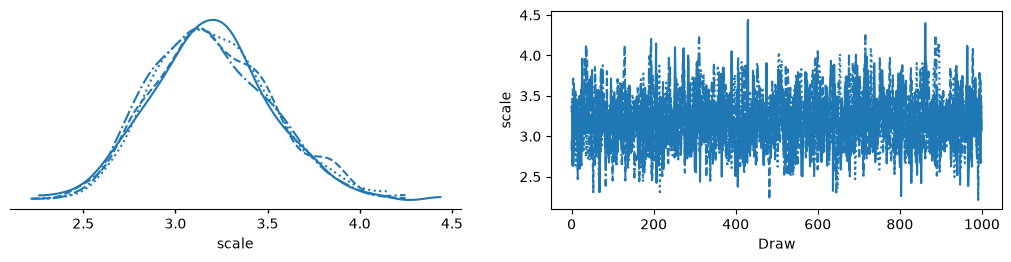

In [36]:
azp.plot_trace_dist(result, var_names=['scale'], );

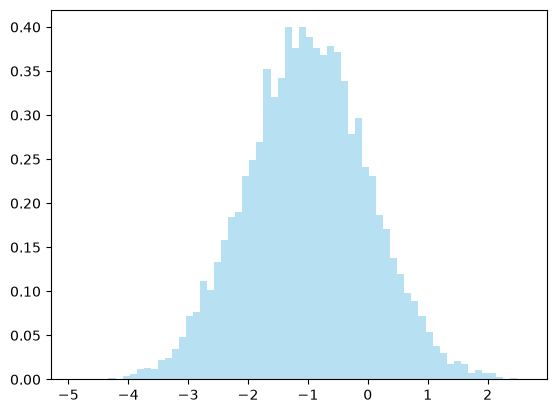

In [37]:
rng_key = jax.random.key(0)
mean = dist.Normal(-1,1)
samples = mean.sample(rng_key, sample_shape=(10000,))
plt.figure()
plt.hist(samples, bins=64, density=True, alpha=0.6, color="skyblue")
plt.show()
